In [1]:
import os

In [2]:
import warnings
warnings.filterwarnings('ignore')
# Get all the paths
dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'

if not os.path.isdir(dataset_dir):
    alternative_dir = (
        r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
        r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
    )

    if os.path.isdir(alternative_dir):
        dataset_dir = alternative_dir
    else:
        raise FileNotFoundError(
            f"Dataset directory not found: {dataset_dir}"
        )

data_dir_list = os.listdir(dataset_dir)
print(data_dir_list)
path, dirs, files = next(os.walk(dataset_dir))
file_count = len(files)
#print(file_count)

['Augmentation Details.txt', 'Benign cases', 'Malignant cases', 'Normal cases', 'Split_data_CNN_0', 'Split_data_inception_V3_1', 'Split_data_vgg16_o', 'train', 'validation']


In [3]:

# Make new base directory
original_dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
base_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_CNN_0'
os.makedirs(base_dir, exist_ok=True)

In [4]:
#create two folders (train and validation)
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)

In [5]:
#Under train folder create two folders

train_cloud_dir = os.path.join(train_dir, 'Benign cases')
os.makedirs(train_cloud_dir, exist_ok=True)

train_foggy_dir = os.path.join(train_dir, 'Malignant cases')
os.makedirs(train_foggy_dir, exist_ok=True)

In [6]:
#Under validation folder create two folders

validation_cloud_dir = os.path.join(validation_dir, 'Benign cases')
os.makedirs(validation_cloud_dir, exist_ok=True)

validation_foggy_dir = os.path.join(validation_dir, 'Malignant cases')
os.makedirs(validation_foggy_dir, exist_ok=True)

In [7]:
import os
import random
from shutil import copyfile

In [8]:
def split_data(SOURCE, TRAINING, VALIDATION, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = SOURCE + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    valid_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    valid_set = shuffled_set[training_length:]

    for filename in training_set:
        this_file = SOURCE + filename
        destination = TRAINING + filename
        copyfile(this_file, destination)

    for filename in valid_set:
        this_file = SOURCE + filename
        destination = VALIDATION + filename
        copyfile(this_file, destination)

In [9]:
BENGIN_SOURCE_DIR = os.path.join(original_dataset_dir, 'Benign cases') + os.sep
TRAINING_BENGIN_DIR = os.path.join(base_dir, 'train', 'Benign cases') + os.sep
VALID_BENGIN_DIR = os.path.join(base_dir, 'validation', 'Benign cases') + os.sep

MALIGNANT_SOURCE_DIR = os.path.join(original_dataset_dir, 'Malignant cases') + os.sep
TRAINING_MALIGNANT_DIR = os.path.join(base_dir, 'train', 'Malignant cases') + os.sep
VALID_MALIGNANT_DIR = os.path.join(base_dir, 'validation', 'Malignant cases') + os.sep

In [10]:
from pathlib import Path

split_size = 0.80

os.makedirs(TRAINING_BENGIN_DIR, exist_ok=True)
os.makedirs(VALID_BENGIN_DIR, exist_ok=True)
os.makedirs(TRAINING_MALIGNANT_DIR, exist_ok=True)
os.makedirs(VALID_MALIGNANT_DIR, exist_ok=True)

dataset_root = Path(original_dataset_dir)
excluded_dir = Path(base_dir).resolve()

def find_class_folder(names):
    for folder in dataset_root.rglob("*"):
        if (
            folder.is_dir()
            and folder.resolve() != excluded_dir
            and folder.name.casefold().replace(" ", "").replace("_", "")
            in names
        ):
            return folder
    return None

benign_source = find_class_folder({"benigncases", "bengincases"})
malignant_source = find_class_folder({"malignantcases"})

if benign_source is not None and malignant_source is not None:
    split_data(
        str(benign_source) + os.sep,
        TRAINING_BENGIN_DIR,
        VALID_BENGIN_DIR,
        split_size
    )
    split_data(
        str(malignant_source) + os.sep,
        TRAINING_MALIGNANT_DIR,
        VALID_MALIGNANT_DIR,
        split_size
    )
else:
    existing_split = all(
        any(Path(folder).iterdir())
        for folder in (
            TRAINING_BENGIN_DIR,
            VALID_BENGIN_DIR,
            TRAINING_MALIGNANT_DIR,
            VALID_MALIGNANT_DIR
        )
    )

    if existing_split:
        print("Source folders were not found; using the existing Split_data_CNN folders.")
    else:
        raise FileNotFoundError(
            f"Original class folders were not found below:\n{original_dataset_dir}\n"
            "Add 'Benign cases'/'Bengin cases' and 'Malignant cases' folders, "
            "or populate Split_data_CNN first."
        )

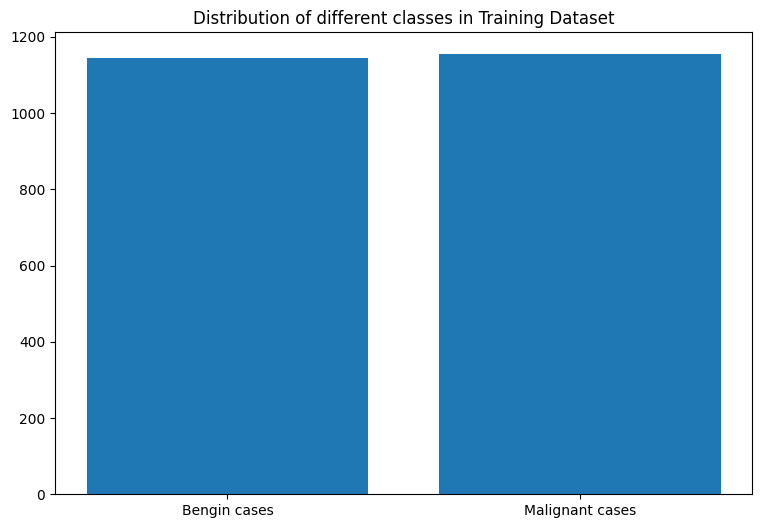

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib

image_folder = ['Bengin cases', 'Malignant cases']
nimgs = {}
for i in image_folder:
    folder_name = 'Benign cases' if i == 'Bengin cases' else i
    nimages = len(os.listdir(os.path.join(train_dir, folder_name)))
    nimgs[i]=nimages
plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Training Dataset')
plt.show()

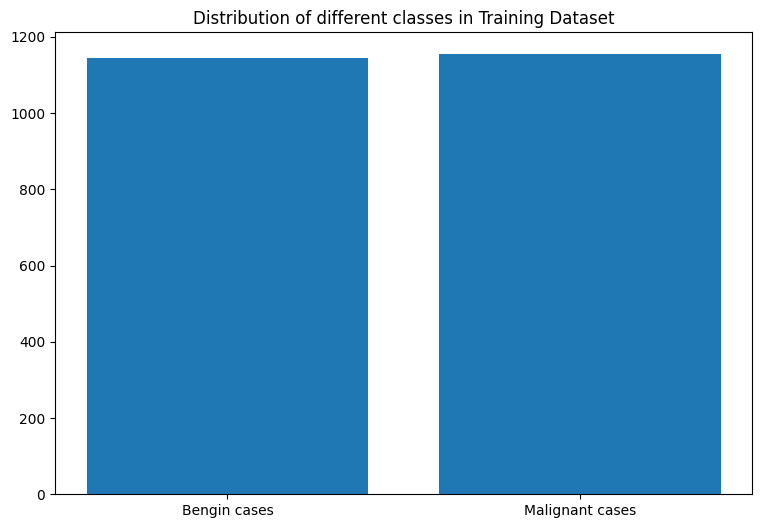

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib

image_folder = ['Bengin cases', 'Malignant cases']
nimgs = {}
for i in image_folder:
    folder_name = 'Benign cases' if i == 'Bengin cases' else i
    nimages = len(os.listdir(os.path.join(train_dir, folder_name)))
    nimgs[i]=nimages
plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Training Dataset')
plt.show()

In [13]:
for i in ['Bengin cases', 'Malignant cases']:
    folder_name = 'Benign cases' if i == 'Bengin cases' else i
    training_path = os.path.join(train_dir, folder_name)
    image_count = len(os.listdir(training_path))
    print(f"Training {i} images are: {image_count}")

Training Bengin cases images are: 1145
Training Malignant cases images are: 1154


In [14]:
validation_folders = {
    'Bengin cases': VALID_BENGIN_DIR,
    'Malignant cases': VALID_MALIGNANT_DIR
}

for class_name, folder_path in validation_folders.items():
    print(
        f"Testing {class_name} images are: "
        f"{len(os.listdir(folder_path))}"
    )

Testing Bengin cases images are: 425
Testing Malignant cases images are: 435


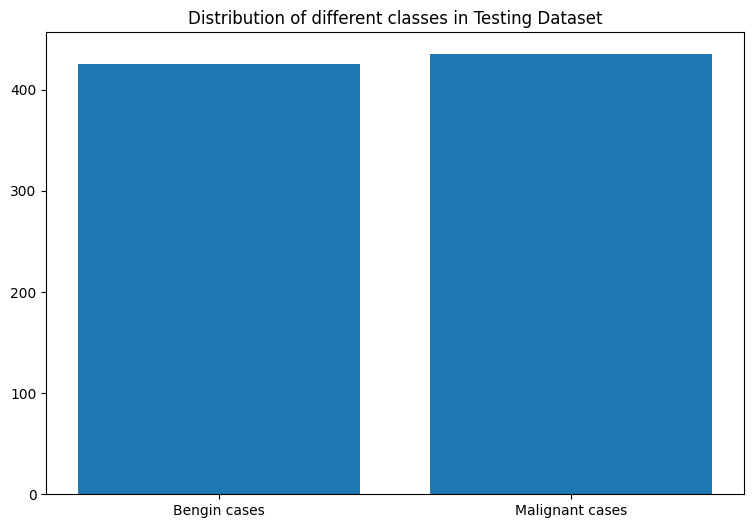

In [15]:
image_folder = ['Bengin cases', 'Malignant cases']
nimgs = {}

for i in image_folder:
    folder_name = 'Benign cases' if i == 'Bengin cases' else i
    validation_path = os.path.join(validation_dir, folder_name)
    nimgs[i] = len(os.listdir(validation_path))

plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Testing Dataset')
plt.show()

In [16]:
!pip install tensorflow==2.20.0


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Dropout
from keras.layers import Flatten

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [20]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=8,
                                   zoom_range=0.15,
                                   width_shift_range=0.15,
                                   height_shift_range=0.15,
                                   shear_range=0.10,
                                   horizontal_flip=True,
                                   brightness_range=[0.8,1.2],
                                   channel_shift_range=0.15,
                                   fill_mode="nearest")

In [21]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [22]:
x_train = train_datagen.flow_from_directory(
	train_dir,
	target_size=(224, 224),
	batch_size=32,
	class_mode='binary',
	classes=['Benign cases', 'Malignant cases']
)

x_test = test_datagen.flow_from_directory(
	validation_dir,
	target_size=(224, 224),
	batch_size=32,
	class_mode='binary',
	shuffle=False,
	classes=['Benign cases', 'Malignant cases']
)

print(x_train.class_indices)
print(x_test.class_indices)

Found 2299 images belonging to 2 classes.
Found 860 images belonging to 2 classes.
{'Benign cases': 0, 'Malignant cases': 1}
{'Benign cases': 0, 'Malignant cases': 1}


In [23]:
from tensorflow.keras.layers import Convolution2DTranspose
from tensorflow.keras.models import Sequential
from IPython.core import history
from tensorflow.keras import metrics

In [24]:

model = Sequential()
model.add(Convolution2D (32,(3,3),input_shape=(224,224,3),activation='relu'))
model.add(MaxPooling2D (pool_size=(3,3)))
model.add(Dropout(0.25))
model.add(Convolution2D(64,(3,3),activation='relu'))
model.add(Convolution2D(64,(3,3),activation='relu'))


model.add(MaxPooling2D (pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Convolution2D(128,(3,3),activation='relu'))
model.add(Convolution2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D (pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(units=512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=128,activation='relu'))
model.add(Dense(1,activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 31, 31, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    14,746,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,089,665 (57.56 MB)

 Trainable params: 15,089,665 (57.56 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [26]:
TRAIN_COUNT =len(x_train.filepaths)
TEST_COUNT=len(x_test.filepaths)
TRAIN_STEPS_PER_EPOCH= round(TRAIN_COUNT/32)
VAL_STEPS_PER_EPOCH = round(TEST_COUNT/32)

In [27]:
print(f"TRAIN_STEPS_PER_EPOCH:{TRAIN_STEPS_PER_EPOCH}")
print(f"VAL_STEPS_PER_EPOCH:{VAL_STEPS_PER_EPOCH}")

TRAIN_STEPS_PER_EPOCH:72
VAL_STEPS_PER_EPOCH:27


In [91]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
EARLY_STOP_PATIENCE =5

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

if 'EARLY_STOP_PATIENCE' not in globals():
    EARLY_STOP_PATIENCE = 5

cb_early_stopper = EarlyStopping(monitor='val_loss', patience=EARLY_STOP_PATIENCE)
cb_checkpointer = ModelCheckpoint(filepath='FINAL_CNN.keras', monitor='val_loss', save_best_only=True, mode='auto')
callbacks=[cb_checkpointer, cb_early_stopper]
history = model.fit(x_train, steps_per_epoch=TRAIN_STEPS_PER_EPOCH, epochs=20,
                            validation_data=x_test, validation_steps=VAL_STEPS_PER_EPOCH, callbacks=callbacks)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.5194 - loss: 0.7005 - val_accuracy: 0.5163 - val_loss: 0.6898
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.5268 - loss: 0.6904 - val_accuracy: 0.4942 - val_loss: 0.6937
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.4928 - loss: 0.6936 - val_accuracy: 0.4942 - val_loss: 0.6932
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.4837 - loss: 0.6937 - val_accuracy: 0.4942 - val_loss: 0.6932
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.4928 - loss: 0.6935 - val_accuracy: 0.5058 - val_loss: 0.6931
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.4846 - loss: 0.6936 - val_accuracy: 0.4942 - val_loss: 0.6933
